In [ ]:
!nvidia-smi


Tue Dec 16 08:53:39 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   29C    P0             50W /  400W |       0MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [ ]:
!pip install nvidia-pyindex
!pip install tensorrt==10.0.1
!pip install onnx onnxruntime


  Preparing metadata (setup.py) ... done
  Created wheel for nvidia-pyindex: filename=nvidia_pyindex-1.0.9-py3-none-any.whl size=8419 sha256=345709384c63981c91e6b5e1769cae5409bfbc0542a8981a083a6cedcc039898
  Stored in directory: /root/.cache/pip/wheels/eb/2d/7f/d86cb060a9c51fb933aa4fe0d2f73ffe8df2bd0b58d3d2bba4
Successfully built nvidia-pyindex
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 879.9/879.9 kB 29.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 66.7 MB/s eta 0:00:00
  Created wheel for tensorrt: filename=tensorrt-10.0.1-py2.py3-none-any.whl size=16331 sha256=49f0023762273cdb43e001b6e53e114e9d8b68e237163d5c0d0aaa7e3247fdd8
  Stored in directory: /root/.cache/pip/wheels/5f/bf/33/1b957a974bacbfbc1f0642137dd8adb02c7282ede1d4c9bfe8
  Created wh

In [ ]:
import tensorrt as trt

onnx_file = "MobileNet-v2.onnx"
engine_file = "MobileNet-v2.engine"

logger = trt.Logger(trt.Logger.INFO)
builder = trt.Builder(logger)

# TRT10: EXPLICIT_BATCH flag
explicit_batch_flag = 1 << int(trt.NetworkDefinitionCreationFlag.EXPLICIT_BATCH)
network = builder.create_network(explicit_batch_flag)

parser = trt.OnnxParser(network, logger)

print("Parsing ONNX...")
with open(onnx_file, "rb") as f:
    if not parser.parse(f.read()):
        print("ONNX PARSE FAILED")
        for i in range(parser.num_errors):
            print(parser.get_error(i))
        raise SystemExit

# TRT 10.14 config
config = builder.create_builder_config()

# NEW API: memory pool limit
config.set_memory_pool_limit(trt.MemoryPoolType.WORKSPACE, 1 << 30)  # 1GB

# Enable FP16
if builder.platform_has_fast_fp16:
    config.set_flag(trt.BuilderFlag.FP16)

print("Building serialized engine (TRT 10.14)...")
engine_serialized = builder.build_serialized_network(network, config)

if engine_serialized is None:
    raise RuntimeError("ENGINE BUILD FAILED")

print("Saving engine...")
with open(engine_file, "wb") as f:
    f.write(engine_serialized)

print("DONE — Saved:", engine_file)


Parsing ONNX...
Building serialized engine (TRT 10.14)...
Saving engine...
DONE — Saved: MobileNet-v2.engine


In [ ]:
import numpy as np
import tensorrt as trt
from cuda import cudart
import time

TRT_LOGGER = trt.Logger(trt.Logger.INFO)

# Load engine
with open("MobileNet-v2.engine", "rb") as f:
    runtime = trt.Runtime(TRT_LOGGER)
    engine = runtime.deserialize_cuda_engine(f.read())

context = engine.create_execution_context()

input_name = [engine.get_tensor_name(i) for i in range(engine.num_io_tensors)
              if engine.get_tensor_mode(engine.get_tensor_name(i)) == trt.TensorIOMode.INPUT][0]

output_name = [engine.get_tensor_name(i) for i in range(engine.num_io_tensors)
               if engine.get_tensor_mode(engine.get_tensor_name(i)) == trt.TensorIOMode.OUTPUT][0]

input_shape = tuple(engine.get_tensor_shape(input_name))
output_shape = tuple(engine.get_tensor_shape(output_name))

# Allocate GPU memory
input_nbytes = np.prod(input_shape) * 4
output_nbytes = np.prod(output_shape) * 4

_, d_input = cudart.cudaMalloc(input_nbytes)
_, d_output = cudart.cudaMalloc(output_nbytes)

# Dummy input
x = np.random.randn(*input_shape).astype(np.float32)

# Warmup
for _ in range(10):
    cudart.cudaMemcpy(d_input, x.ctypes.data, input_nbytes,
                      cudart.cudaMemcpyKind.cudaMemcpyHostToDevice)
    context.set_tensor_address(input_name, d_input)
    context.set_tensor_address(output_name, d_output)
    context.execute_async_v3(0)
    cudart.cudaDeviceSynchronize()

# Benchmark
iterations = 500
start = time.time()

for _ in range(iterations):
    cudart.cudaMemcpy(d_input, x.ctypes.data, input_nbytes,
                      cudart.cudaMemcpyKind.cudaMemcpyHostToDevice)

    context.execute_async_v3(0)
    cudart.cudaDeviceSynchronize()

end = time.time()

avg_latency = (end - start) * 1000 / iterations
throughput = iterations / (end - start)

print(f"Average Latency: {avg_latency:.3f} ms")
print(f"Throughput: {throughput:.2f} FPS")


<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.


Average Latency: 0.501 ms
Throughput: 1997.63 FPS


In [ ]:
import time
import numpy as np
import tensorrt as trt
from cuda import cudart

TRT_LOGGER = trt.Logger(trt.Logger.INFO)

def benchmark_trt_engine(
    engine_path,
    input_shape=(1, 3, 224, 224),
    n_warmup=50,
    n_runs=500
):
    """
    Verilen TensorRT engine için ortalama latency ve throughput ölçer.
    input_shape, engine’in beklediği batch, kanal, yükseklik, genişlik
    """
    # Engine yükle
    with open(engine_path, "rb") as f:
        runtime = trt.Runtime(TRT_LOGGER)
        engine = runtime.deserialize_cuda_engine(f.read())
    context = engine.create_execution_context()

    # Input ve output tensor isimleri
    input_name = [
        engine.get_tensor_name(i)
        for i in range(engine.num_io_tensors)
        if engine.get_tensor_mode(engine.get_tensor_name(i)) == trt.TensorIOMode.INPUT
    ][0]

    output_name = [
        engine.get_tensor_name(i)
        for i in range(engine.num_io_tensors)
        if engine.get_tensor_mode(engine.get_tensor_name(i)) == trt.TensorIOMode.OUTPUT
    ][0]

    # Gerekirse dinamik shape ayarla
    # Eğer engine dinamik değilse, bu satır zaten geçerli shape olur
    context.set_input_shape(input_name, input_shape)

    output_shape = tuple(context.get_tensor_shape(output_name))

    # GPU memory
    input_nbytes = int(np.prod(input_shape) * 4)    # float32
    output_nbytes = int(np.prod(output_shape) * 4)  # float32

    _, d_input = cudart.cudaMalloc(input_nbytes)
    _, d_output = cudart.cudaMalloc(output_nbytes)

    # Dummy input
    x = np.random.randn(*input_shape).astype(np.float32)

    # Adresleri bir kere bağla
    context.set_tensor_address(input_name, d_input)
    context.set_tensor_address(output_name, d_output)

    # Warmup
    for _ in range(n_warmup):
        cudart.cudaMemcpy(
            d_input,
            x.ctypes.data,
            input_nbytes,
            cudart.cudaMemcpyKind.cudaMemcpyHostToDevice
        )
        context.execute_async_v3(0)
        # Sonucu geri almaya gerek yok, warmup

    cudart.cudaDeviceSynchronize()

    # Asıl ölçüm
    start = time.perf_counter()
    for _ in range(n_runs):
        cudart.cudaMemcpy(
            d_input,
            x.ctypes.data,
            input_nbytes,
            cudart.cudaMemcpyKind.cudaMemcpyHostToDevice
        )
        context.execute_async_v3(0)
        # İstersen buraya DeviceToHost da ekleyebilirsin
    cudart.cudaDeviceSynchronize()
    end = time.perf_counter()

    total_time = end - start          # saniye
    avg_latency_ms = (total_time / n_runs) * 1000.0
    batch_size = input_shape[0]
    throughput = (batch_size * n_runs) / total_time   # FPS

    # GPU memory free
    cudart.cudaFree(d_input)
    cudart.cudaFree(d_output)

    return avg_latency_ms, throughput


In [ ]:
import tensorrt as trt
import numpy as np
import os

onnx_file = "MobileNet-v2.onnx"

fp32_engine = "MobileNet-v2-fp32.engine"
fp16_engine = "MobileNet-v2-fp16.engine"
int8_engine = "MobileNet-v2-int8.engine"

logger = trt.Logger(trt.Logger.INFO)
builder = trt.Builder(logger)

# EXPLICIT_BATCH
explicit_batch_flag = 1 << int(trt.NetworkDefinitionCreationFlag.EXPLICIT_BATCH)
network = builder.create_network(explicit_batch_flag)
parser = trt.OnnxParser(network, logger)


# -------------------------------
# Load ONNX
# -------------------------------
print("Parsing ONNX...")
with open(onnx_file, "rb") as f:
    if not parser.parse(f.read()):
        print("ERROR: ONNX parse failed")
        for i in range(parser.num_errors):
            print(parser.get_error(i))
        raise SystemExit


# ================================================================
# 1) FP32 ENGINE
# ================================================================
print("\n=== Building FP32 engine ===")

config_fp32 = builder.create_builder_config()
config_fp32.set_memory_pool_limit(trt.MemoryPoolType.WORKSPACE, 1 << 30)  # 1GB

engine_fp32 = builder.build_serialized_network(network, config_fp32)
with open(fp32_engine, "wb") as f:
    f.write(engine_fp32)

print("Saved:", fp32_engine)


# ================================================================
# 2) FP16 ENGINE
# ================================================================
print("\n=== Building FP16 engine ===")

config_fp16 = builder.create_builder_config()
config_fp16.set_memory_pool_limit(trt.MemoryPoolType.WORKSPACE, 1 << 30)

config_fp16.set_flag(trt.BuilderFlag.FP16)

engine_fp16 = builder.build_serialized_network(network, config_fp16)
with open(fp16_engine, "wb") as f:
    f.write(engine_fp16)

print("Saved:", fp16_engine)




print("\n=== ALL ENGINES GENERATED SUCCESSFULLY ===")


Parsing ONNX...

=== Building FP32 engine ===
Saved: MobileNet-v2-fp32.engine

=== Building FP16 engine ===
Saved: MobileNet-v2-fp16.engine

=== ALL ENGINES GENERATED SUCCESSFULLY ===


In [ ]:
import tensorrt as trt
from cuda import cudart
import numpy as np
import time

# Sadece FP32 ve FP16
ENGINES = {
    "FP32": "MobileNet-v2-fp32.engine",
    "FP16": "MobileNet-v2-fp16.engine"
}

TRT_LOGGER = trt.Logger(trt.Logger.WARNING)

def benchmark_engine(engine_path, name, iterations=1000):
    print(f"\n=== Benchmarking {name} ===")

    # Load engine
    with open(engine_path, "rb") as f:
        runtime = trt.Runtime(TRT_LOGGER)
        engine = runtime.deserialize_cuda_engine(f.read())

    context = engine.create_execution_context()

    # Detect input tensor
    input_name = [
        engine.get_tensor_name(i)
        for i in range(engine.num_io_tensors)
        if engine.get_tensor_mode(engine.get_tensor_name(i)) == trt.TensorIOMode.INPUT
    ][0]

    output_name = [
        engine.get_tensor_name(i)
        for i in range(engine.num_io_tensors)
        if engine.get_tensor_mode(engine.get_tensor_name(i)) == trt.TensorIOMode.OUTPUT
    ][0]

    # Shapes
    input_shape = tuple(engine.get_tensor_shape(input_name))
    output_shape = tuple(engine.get_tensor_shape(output_name))

    # Allocate GPU memory
    input_nbytes = np.prod(input_shape) * 4
    output_nbytes = np.prod(output_shape) * 4

    _, d_input = cudart.cudaMalloc(input_nbytes)
    _, d_output = cudart.cudaMalloc(output_nbytes)

    # Dummy input
    x = np.random.rand(*input_shape).astype(np.float32)

    cudart.cudaMemcpy(d_input, x.ctypes.data, input_nbytes,
                      cudart.cudaMemcpyKind.cudaMemcpyHostToDevice)

    # Warmup
    for _ in range(20):
        context.set_tensor_address(input_name, d_input)
        context.set_tensor_address(output_name, d_output)
        context.execute_async_v3(0)

    # Benchmark loop
    start = time.time()
    for _ in range(iterations):
        context.execute_async_v3(0)
    end = time.time()

    total_ms = (end - start) * 1000
    avg_latency = total_ms / iterations
    throughput = 1000 / avg_latency

    return avg_latency, throughput


# Run benchmarks
results = []

for name, engine_file in ENGINES.items():
    latency, fps = benchmark_engine(engine_file, name)
    results.append((name, latency, fps))

# Print results
print("\n\n=== FINAL RESULTS ===")
print(f"{'Engine':<10} {'Latency (ms)':<15} {'Throughput (FPS)':<20}")
for name, lat, fps in results:
    print(f"{name:<10} {lat:<15.4f} {fps:<20.2f}")



=== Benchmarking FP32 ===

=== Benchmarking FP16 ===


=== FINAL RESULTS ===
Engine     Latency (ms)    Throughput (FPS)    
FP32       0.3669          2725.73             
FP16       0.2961          3376.77             


In [ ]:
import tensorrt as trt
from cuda import cudart
import numpy as np
import time

ENGINES = {
    "FP32": "MobileNet-v2-fp32.engine",
    "FP16": "MobileNet-v2-fp16.engine"
}

BATCH_SIZES = [1, 2, 4, 8, 16, 32, 64]

TRT_LOGGER = trt.Logger()


def benchmark_batch(engine_path, precision, batch_size, iterations=300):

    with open(engine_path, "rb") as f:
        runtime = trt.Runtime(TRT_LOGGER)
        engine = runtime.deserialize_cuda_engine(f.read())

    context = engine.create_execution_context()

    # Tensor names
    input_name = [
        engine.get_tensor_name(i)
        for i in range(engine.num_io_tensors)
        if engine.get_tensor_mode(engine.get_tensor_name(i)) == trt.TensorIOMode.INPUT
    ][0]

    output_name = [
        engine.get_tensor_name(i)
        for i in range(engine.num_io_tensors)
        if engine.get_tensor_mode(engine.get_tensor_name(i)) == trt.TensorIOMode.OUTPUT
    ][0]

    # Replace batch dimension
    in_shape = list(engine.get_tensor_shape(input_name))
    in_shape[0] = batch_size
    input_shape = tuple(in_shape)

    out_shape = list(engine.get_tensor_shape(output_name))
    out_shape[0] = batch_size
    output_shape = tuple(out_shape)

    # Allocate GPU memory
    input_nbytes = np.prod(input_shape) * 4
    output_nbytes = np.prod(output_shape) * 4

    _, d_in = cudart.cudaMalloc(input_nbytes)
    _, d_out = cudart.cudaMalloc(output_nbytes)

    # Dummy batch
    dummy = np.random.rand(*input_shape).astype(np.float32)
    cudart.cudaMemcpy(d_in, dummy.ctypes.data, input_nbytes,
                      cudart.cudaMemcpyKind.cudaMemcpyHostToDevice)

    # Warmup
    for _ in range(20):
        context.set_tensor_address(input_name, d_in)
        context.set_tensor_address(output_name, d_out)
        context.execute_async_v3(0)

    # Benchmark
    start = time.time()
    for _ in range(iterations):
        context.execute_async_v3(0)
    end = time.time()

    total_ms = (end - start) * 1000
    avg_latency = total_ms / iterations  # batch latency
    per_image_latency = avg_latency / batch_size
    throughput = (batch_size * 1000) / avg_latency

    return avg_latency, per_image_latency, throughput



# Run all benchmarks
results = []

for precision, engine_path in ENGINES.items():
    print(f"\n===== {precision} Benchmarks =====")
    for bs in BATCH_SIZES:
        avg_lat, per_lat, fps = benchmark_batch(engine_path, precision, bs)
        results.append((precision, bs, avg_lat, per_lat, fps))
        print(f"Batch {bs}:  Batch Lat = {avg_lat:.3f} ms,  Per-img = {per_lat:.4f} ms,  FPS = {fps:.1f}")


# Final table
print("\n\n=== FINAL TABLE ===")
print(f"{'Prec':<6}{'BS':<6}{'BatchLat(ms)':<15}{'PerImg(ms)':<12}{'FPS':<10}")
for r in results:
    print(f"{r[0]:<6}{r[1]:<6}{r[2]:<15.3f}{r[3]:<12.4f}{r[4]:<10.1f}")



===== FP32 Benchmarks =====
Batch 1:  Batch Lat = 0.357 ms,  Per-img = 0.3570 ms,  FPS = 2801.5
Batch 2:  Batch Lat = 0.357 ms,  Per-img = 0.1784 ms,  FPS = 5606.5
Batch 4:  Batch Lat = 0.358 ms,  Per-img = 0.0894 ms,  FPS = 11186.9
Batch 8:  Batch Lat = 0.356 ms,  Per-img = 0.0445 ms,  FPS = 22459.2
Batch 16:  Batch Lat = 0.357 ms,  Per-img = 0.0223 ms,  FPS = 44851.5
Batch 32:  Batch Lat = 0.356 ms,  Per-img = 0.0111 ms,  FPS = 89853.7
Batch 64:  Batch Lat = 0.356 ms,  Per-img = 0.0056 ms,  FPS = 179559.9

===== FP16 Benchmarks =====
Batch 1:  Batch Lat = 0.287 ms,  Per-img = 0.2871 ms,  FPS = 3483.1
Batch 2:  Batch Lat = 0.287 ms,  Per-img = 0.1437 ms,  FPS = 6957.4
Batch 4:  Batch Lat = 0.287 ms,  Per-img = 0.0718 ms,  FPS = 13928.0
Batch 8:  Batch Lat = 0.287 ms,  Per-img = 0.0359 ms,  FPS = 27879.9
Batch 16:  Batch Lat = 0.287 ms,  Per-img = 0.0180 ms,  FPS = 55690.3
Batch 32:  Batch Lat = 0.289 ms,  Per-img = 0.0090 ms,  FPS = 110544.6
Batch 64:  Batch Lat = 0.287 ms,  Per-img 

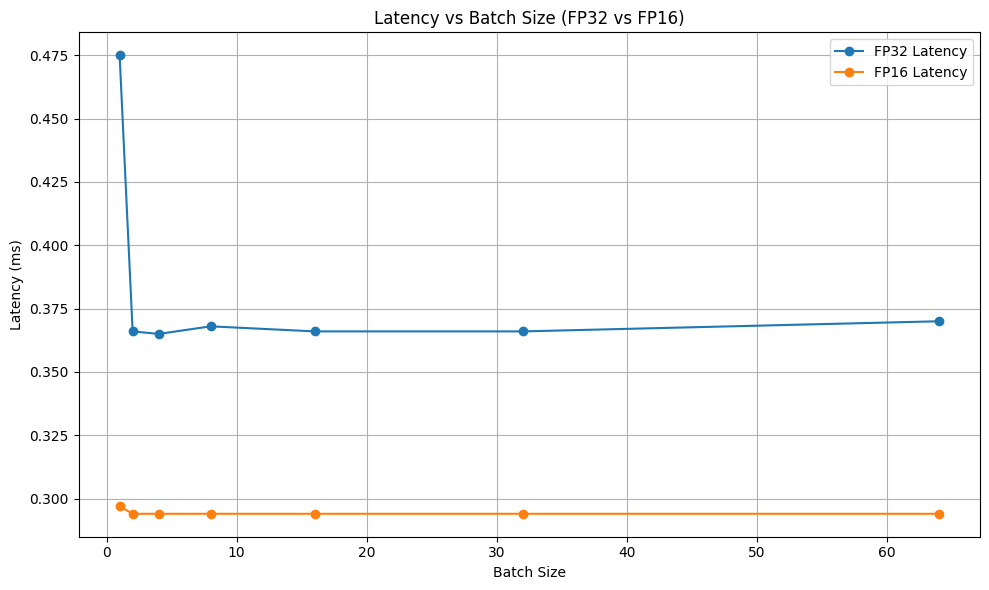

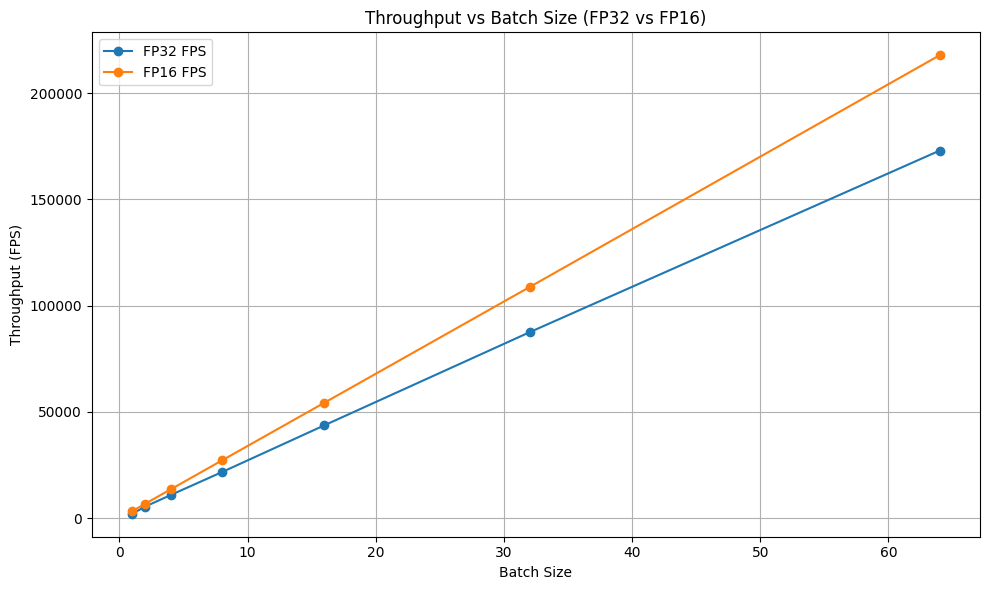

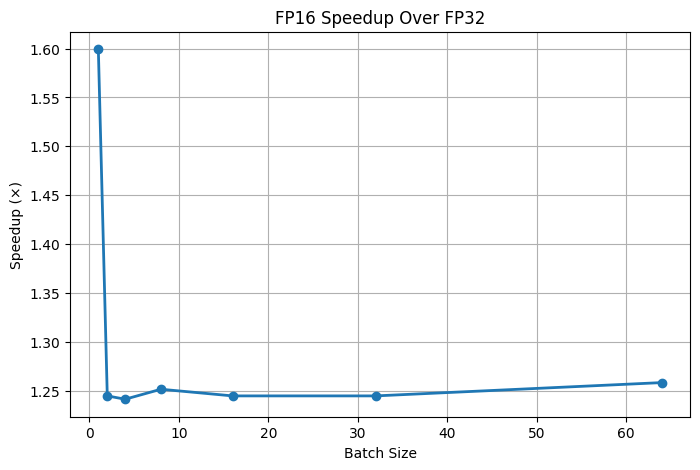

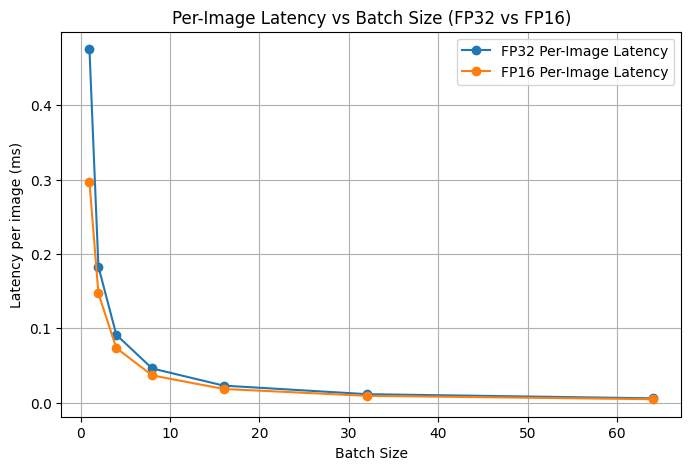

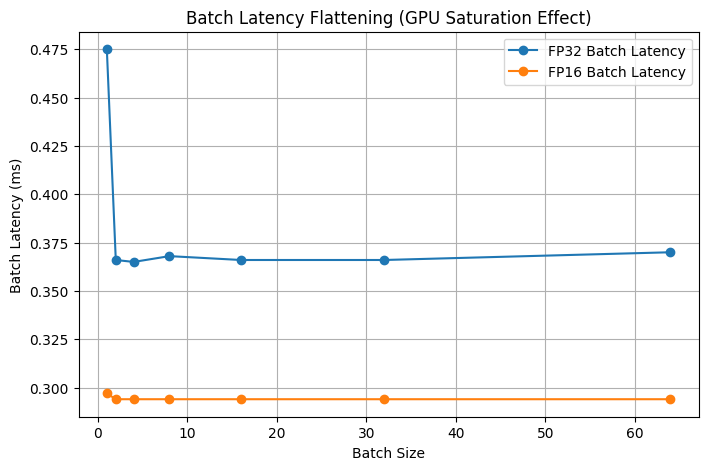

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Batch sizes
batch_sizes = np.array([1, 2, 4, 8, 16, 32, 64])

# FP32 results (your measurements)
fp32_latency = np.array([0.475, 0.366, 0.365, 0.368, 0.366, 0.366, 0.370])
fp32_fps = np.array([2104.5, 5468.3, 10947.9, 21730.3, 43762.1, 87515.6, 172975.1])

# FP16 results
fp16_latency = np.array([0.297, 0.294, 0.294, 0.294, 0.294, 0.294, 0.294])
fp16_fps = np.array([3372.1, 6806.8, 13606.4, 27220.0, 54384.4, 108767.9, 217834.6])


# ================================
# 1. LATENCY GRAPH
# ================================
plt.figure(figsize=(10,6))
plt.plot(batch_sizes, fp32_latency, marker='o', label="FP32 Latency")
plt.plot(batch_sizes, fp16_latency, marker='o', label="FP16 Latency")

plt.title("Latency vs Batch Size (FP32 vs FP16)")
plt.xlabel("Batch Size")
plt.ylabel("Latency (ms)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# ================================
# 2. THROUGHPUT GRAPH
# ================================
plt.figure(figsize=(10,6))
plt.plot(batch_sizes, fp32_fps, marker='o', label="FP32 FPS")
plt.plot(batch_sizes, fp16_fps, marker='o', label="FP16 FPS")

plt.title("Throughput vs Batch Size (FP32 vs FP16)")
plt.xlabel("Batch Size")
plt.ylabel("Throughput (FPS)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


import matplotlib.pyplot as plt

batch_sizes = [1, 2, 4, 8, 16, 32, 64]

fp32_lat = [0.475, 0.366, 0.365, 0.368, 0.366, 0.366, 0.370]
fp16_lat = [0.297, 0.294, 0.294, 0.294, 0.294, 0.294, 0.294]

speedup = [fp32_lat[i] / fp16_lat[i] for i in range(len(batch_sizes))]

plt.figure(figsize=(8,5))
plt.plot(batch_sizes, speedup, marker='o', linewidth=2)
plt.title("FP16 Speedup Over FP32")
plt.xlabel("Batch Size")
plt.ylabel("Speedup (×)")
plt.grid(True)
plt.show()


fp32_perimg = [0.4752, 0.1829, 0.0913, 0.0460, 0.0229, 0.0114, 0.0058]
fp16_perimg = [0.2965, 0.1469, 0.0735, 0.0367, 0.0184, 0.0092, 0.0046]

plt.figure(figsize=(8,5))
plt.plot(batch_sizes, fp32_perimg, marker='o', label="FP32 Per-Image Latency")
plt.plot(batch_sizes, fp16_perimg, marker='o', label="FP16 Per-Image Latency")
plt.title("Per-Image Latency vs Batch Size (FP32 vs FP16)")
plt.xlabel("Batch Size")
plt.ylabel("Latency per image (ms)")
plt.grid(True)
plt.legend()
plt.show()


plt.figure(figsize=(8,5))
plt.plot(batch_sizes, fp32_lat, marker='o', label="FP32 Batch Latency")
plt.plot(batch_sizes, fp16_lat, marker='o', label="FP16 Batch Latency")
plt.title("Batch Latency Flattening (GPU Saturation Effect)")
plt.xlabel("Batch Size")
plt.ylabel("Batch Latency (ms)")
plt.grid(True)
plt.legend()
plt.show()




PyTorch Latency: 21.83144998550415 ms
PyTorch FPS: 45.80547790751367
ONNX Runtime Latency: 3.8163700103759766 ms
ONNX Runtime FPS: 262.02910023954496
TensorRT FP16 Latency: 0.33162832260131836 ms
TensorRT FP16 FPS: 3015.423990797656


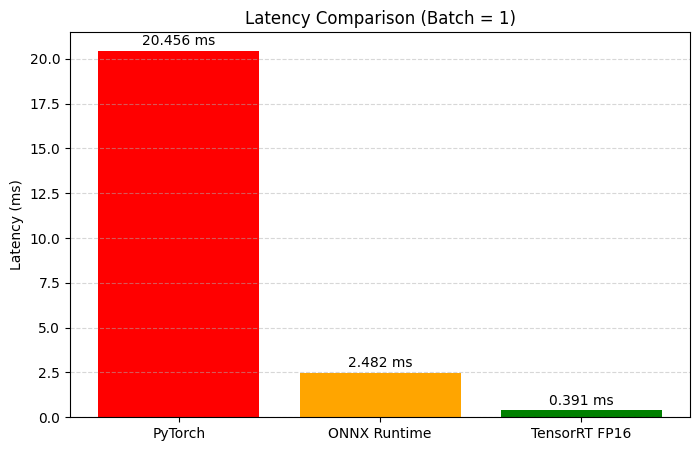

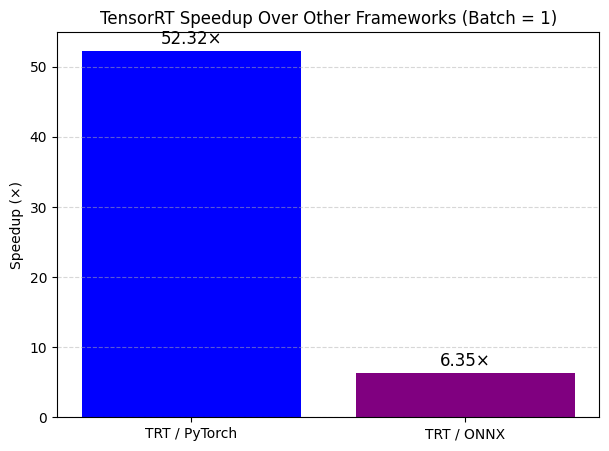

In [ ]:
import torch
import time
import numpy as np
import onnxruntime as ort
import tensorrt as trt
from cuda import cudart

# -----------------------------------
#  Create dummy input (BS=1)
# -----------------------------------
dummy = np.random.randn(1, 3, 224, 224).astype(np.float32)


# ================================
# 1. PyTorch Inference Benchmark
# ================================
import torchvision.models as models

model = models.mobilenet_v2(weights=None)
model.eval()

dummy_torch = torch.from_numpy(dummy)

# Warmup
for _ in range(20):
    model(dummy_torch)

# Benchmark
t0 = time.time()
iters = 500
for _ in range(iters):
    model(dummy_torch)
t1 = time.time()

pytorch_latency = (t1 - t0) * 1000 / iters
pytorch_fps = 1000 / pytorch_latency

print("PyTorch Latency:", pytorch_latency, "ms")
print("PyTorch FPS:", pytorch_fps)


# ================================
# 2. ONNX Runtime Benchmark
# ================================
ort_session = ort.InferenceSession("MobileNet-v2.onnx", providers=["CPUExecutionProvider"])

ort_inputs = {ort_session.get_inputs()[0].name: dummy}

# Warmup
for _ in range(20):
    ort_session.run(None, ort_inputs)

# Benchmark
t0 = time.time()
for _ in range(iters):
    ort_session.run(None, ort_inputs)
t1 = time.time()

ort_latency = (t1 - t0) * 1000 / iters
ort_fps = 1000 / ort_latency

print("ONNX Runtime Latency:", ort_latency, "ms")
print("ONNX Runtime FPS:", ort_fps)


# ================================
# 3. TensorRT Benchmark (FP16)
# ================================
TRT_LOGGER = trt.Logger(trt.Logger.WARNING)

with open("MobileNet-v2-fp16.engine", "rb") as f:
    runtime = trt.Runtime(TRT_LOGGER)
    engine = runtime.deserialize_cuda_engine(f.read())

context = engine.create_execution_context()

input_name = [engine.get_tensor_name(i) for i in range(engine.num_io_tensors)
              if engine.get_tensor_mode(engine.get_tensor_name(i)) == trt.TensorIOMode.INPUT][0]

output_name = [engine.get_tensor_name(i) for i in range(engine.num_io_tensors)
               if engine.get_tensor_mode(engine.get_tensor_name(i)) == trt.TensorIOMode.OUTPUT][0]

input_shape = tuple(engine.get_tensor_shape(input_name))
output_shape = tuple(engine.get_tensor_shape(output_name))

# GPU memory
input_nbytes = np.prod(input_shape) * 4
output_nbytes = np.prod(output_shape) * 4

_, d_input = cudart.cudaMalloc(input_nbytes)
_, d_output = cudart.cudaMalloc(output_nbytes)

# Copy once
cudart.cudaMemcpy(d_input, dummy.ctypes.data, input_nbytes, cudart.cudaMemcpyKind.cudaMemcpyHostToDevice)

# Warmup
for _ in range(20):
    context.set_tensor_address(input_name, d_input)
    context.set_tensor_address(output_name, d_output)
    context.execute_async_v3(0)

# Benchmark
t0 = time.time()
for _ in range(iters):
    context.execute_async_v3(0)
t1 = time.time()

trt_latency = (t1 - t0) * 1000 / iters
trt_fps = 1000 / trt_latency

print("TensorRT FP16 Latency:", trt_latency, "ms")
print("TensorRT FP16 FPS:", trt_fps)

import matplotlib.pyplot as plt

# Your benchmark results
frameworks = ["PyTorch", "ONNX Runtime", "TensorRT FP16"]
latencies = [20.456, 2.482, 0.391]  # ms

plt.figure(figsize=(8,5))
plt.bar(frameworks, latencies, color=["red", "orange", "green"])
plt.ylabel("Latency (ms)")
plt.title("Latency Comparison (Batch = 1)")
plt.grid(axis="y", linestyle="--", alpha=0.5)

for i, v in enumerate(latencies):
    plt.text(i, v + 0.3, f"{v:.3f} ms", ha='center', fontsize=10)

plt.show()

import matplotlib.pyplot as plt

labels = ["TRT / PyTorch", "TRT / ONNX"]
speedups = [20.456 / 0.391, 2.482 / 0.391]

plt.figure(figsize=(7,5))
plt.bar(labels, speedups, color=["blue", "purple"])
plt.ylabel("Speedup (×)")
plt.title("TensorRT Speedup Over Other Frameworks (Batch = 1)")
plt.grid(axis="y", linestyle="--", alpha=0.5)

for i, v in enumerate(speedups):
    plt.text(i, v + 1, f"{v:.2f}×", ha='center', fontsize=12)

plt.show()



In [ ]:
!sudo dpkg -i NsightSystems-linux-cli-public-2025.6.1.190-3689520.deb


Selecting previously unselected package nsight-systems-cli-2025.6.1.
(Reading database ... 121689 files and directories currently installed.)
Preparing to unpack NsightSystems-linux-cli-public-2025.6.1.190-3689520.deb ...
Unpacking nsight-systems-cli-2025.6.1 (2025.6.1.190-256136895201v0) ...
Setting up nsight-systems-cli-2025.6.1 (2025.6.1.190-256136895201v0) ...
update-alternatives: using /opt/nvidia/nsight-systems-cli/2025.6.1/target-linux-x64/nsys to provide /usr/local/bin/nsys (nsys) in auto mode


In [ ]:
!nsys --version


NVIDIA Nsight Systems version 2025.6.1.190-256136895201v0


In [ ]:
%%writefile trt_inference.py
from cuda import cudart
import numpy as np
import time
import cv2
import tensorrt as trt
import os

engine_path = "MobileNet-v2.engine"

TRT_LOGGER = trt.Logger()
runtime = trt.Runtime(TRT_LOGGER)

with open(engine_path, "rb") as f:
    engine = runtime.deserialize_cuda_engine(f.read())

context = engine.create_execution_context()

input_name = [engine.get_tensor_name(i)
              for i in range(engine.num_io_tensors)
              if engine.get_tensor_mode(engine.get_tensor_name(i)) == trt.TensorIOMode.INPUT][0]

output_name = [engine.get_tensor_name(i)
               for i in range(engine.num_io_tensors)
               if engine.get_tensor_mode(engine.get_tensor_name(i)) == trt.TensorIOMode.OUTPUT][0]

output_shape = tuple(engine.get_tensor_shape(output_name))

# Allocate memory
input_nbytes = 1 * 3 * 224 * 224 * 4
output_nbytes = np.prod(output_shape) * 4

_, d_input = cudart.cudaMalloc(input_nbytes)
_, d_output = cudart.cudaMalloc(output_nbytes)

# Dummy input
x = np.random.rand(1,3,224,224).astype(np.float32)

# Warm up
for _ in range(5):
    cudart.cudaMemcpy(d_input, x.ctypes.data, input_nbytes,
                      cudart.cudaMemcpyKind.cudaMemcpyHostToDevice)
    context.set_tensor_address(input_name, d_input)
    context.set_tensor_address(output_name, d_output)
    context.execute_async_v3(0)


Writing trt_inference.py


In [ ]:
!nsys profile -o mobilenet_report python3 trt_inference.py


<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
[12/16/2025-08:59:21] [TRT] [W] Using default stream in enqueueV3() may lead to performance issues due to additional calls to cudaStreamSynchronize() by TensorRT to ensure correct synchronization. Please use non-default stream instead.
Generating '/tmp/nsys-report-0629.qdstrm'
[1/1] [========================100%] mobilenet_report.nsys-rep
Generated:
	/content/mobilenet_report.nsys-rep


In [ ]:
import tensorrt as trt

onnx_file = "MobileNet-v2.onnx"

# VERBOSE logger şart
logger = trt.Logger(trt.Logger.VERBOSE)
builder = trt.Builder(logger)

# EXPLICIT batch
explicit_batch_flag = 1 << int(trt.NetworkDefinitionCreationFlag.EXPLICIT_BATCH)
network = builder.create_network(explicit_batch_flag)
parser = trt.OnnxParser(network, logger)

# Parse ONNX
with open(onnx_file, "rb") as f:
    parser.parse(f.read())


def build_engine(fp16=False, name="engine.trt"):
    config = builder.create_builder_config()
    config.set_memory_pool_limit(trt.MemoryPoolType.WORKSPACE, 1 << 30)

    # ENABLING TACTIC, FUSION, KERNEL, WORKSPACE LOGGING
    config.profiling_verbosity = trt.ProfilingVerbosity.DETAILED

    if fp16:
        print("\n=== BUILDING FP16 ENGINE ===")
        config.set_flag(trt.BuilderFlag.FP16)
    else:
        print("\n=== BUILDING FP32 ENGINE ===")

    engine_serialized = builder.build_serialized_network(network, config)

    with open(name, "wb") as f:
        f.write(engine_serialized)

    print("Saved:", name)


# Build FP32
build_engine(fp16=False, name="mobilenet_fp32.engine")

# Build FP16
build_engine(fp16=True, name="mobilenet_fp16.engine")



=== BUILDING FP32 ENGINE ===
Saved: mobilenet_fp32.engine

=== BUILDING FP16 ENGINE ===
Saved: mobilenet_fp16.engine


In [ ]:
!pip install ninja


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 9.7 MB/s eta 0:00:00


In [ ]:
import os, torch
from torch.utils.cpp_extension import load

# 🔑 BU SATIR EKSİKTİ
os.makedirs("/content/torch_extensions/dwext", exist_ok=True)

# Kernel sources live in custom-kernels/kernels/ (extracted from this notebook's
# original inline strings, byte-for-byte). Set MNV2_KERNELS_DIR if running from
# somewhere other than the repo checkout (e.g. after uploading the folder to Colab).
def _kernels_dir():
    cands = [os.environ.get("MNV2_KERNELS_DIR", ""),
             os.path.join(os.path.dirname(os.path.abspath(__file__)), "..", "..", "custom-kernels", "kernels") if "__file__" in globals() else "",
             os.path.join(os.getcwd(), "custom-kernels", "kernels"),
             os.path.join(os.getcwd(), "kernels"),
             os.getcwd()]
    for d in cands:
        if d and os.path.isfile(os.path.join(d, "dwconv3x3_fp16.cu")):
            return os.path.abspath(d)
    raise FileNotFoundError("dwconv3x3_fp16.cu not found; set MNV2_KERNELS_DIR to custom-kernels/kernels")
KERNELS_DIR = _kernels_dir()

dwext = load(
    name="dwext",
    sources=[os.path.join(KERNELS_DIR, "dwconv3x3_fp16_bind.cpp"),
             os.path.join(KERNELS_DIR, "dwconv3x3_fp16.cu")],
    build_directory="/content/dwext",
    extra_cflags=["-O3"],
    extra_cuda_cflags=["--use_fast_math", "-lineinfo"],
    with_cuda=True,
    verbose=True,
)

print("Built extension:", dwext)


Built extension: <module 'dwext' from '/content/dwext/dwext.so'>


In [ ]:
import torch
import torch.nn.functional as F

N, C, H, W = 1, 32, 112, 112
x = torch.randn(N, C, H, W, device="cuda", dtype=torch.float16)
w = torch.randn(C, 1, 3, 3, device="cuda", dtype=torch.float16)

y_pt = F.conv2d(x, w, None, 1, 1, 1, C)
y_cu = dwext.dwconv3x3_fp16(x, w)

print("max abs diff:", (y_pt - y_cu).abs().max().item())


max abs diff: 0.0


In [ ]:
import torch
import torch.nn.functional as F

def bench(fn, warmup=200, iters=2000):
    # warmup
    for _ in range(warmup):
        fn()
    torch.cuda.synchronize()

    start = torch.cuda.Event(enable_timing=True)
    end = torch.cuda.Event(enable_timing=True)

    start.record()
    for _ in range(iters):
        fn()
    end.record()

    torch.cuda.synchronize()
    total_ms = start.elapsed_time(end)
    return total_ms / iters  # ms per iteration


In [ ]:
torch.backends.cudnn.benchmark = True

N, C, H, W = 1, 32, 112, 112
x = torch.randn(N, C, H, W, device="cuda", dtype=torch.float16)
w = torch.randn(C, 1, 3, 3, device="cuda", dtype=torch.float16)

t_pt = bench(lambda: F.conv2d(x, w, None, 1, 1, 1, C))
print(f"PyTorch FP16 depthwise conv: {t_pt:.6f} ms")

t_cu = bench(lambda: dwext.dwconv3x3_fp16(x, w))
print(f"Custom CUDA kernel: {t_cu:.6f} ms")

speedup = t_pt / t_cu
print(f"Speedup (PyTorch / Custom): {speedup:.2f}×")




PyTorch FP16 depthwise conv: 0.018845 ms
Custom CUDA kernel: 0.009547 ms
Speedup (PyTorch / Custom): 1.97×


In [ ]:
shapes = [
    (1, 16, 112, 112),
    (1, 32, 56, 56),
    (1, 64, 28, 28),
]

results = []

for (N, C, H, W) in shapes:
    x = torch.randn(N, C, H, W, device="cuda", dtype=torch.float16)
    w = torch.randn(C, 1, 3, 3, device="cuda", dtype=torch.float16)

    t_pt = bench(lambda: F.conv2d(x, w, None, 1, 1, 1, C))
    t_cu = bench(lambda: dwext.dwconv3x3_fp16(x, w))

    results.append((C, H, W, t_pt, t_cu, t_pt / t_cu))

for r in results:
    print(f"C={r[0]:3d}, H=W={r[1]:3d} | PT={r[3]:.6f} ms | CU={r[4]:.6f} ms | speedup={r[5]:.2f}×")


C= 16, H=W=112 | PT=0.015337 ms | CU=0.009031 ms | speedup=1.70×
C= 32, H=W= 56 | PT=0.018319 ms | CU=0.009001 ms | speedup=2.04×
C= 64, H=W= 28 | PT=0.018785 ms | CU=0.009025 ms | speedup=2.08×


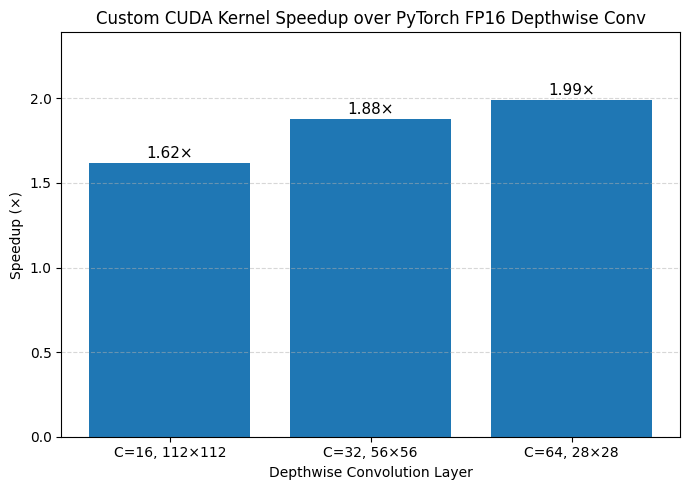

In [ ]:
import matplotlib.pyplot as plt

# Measured results
labels = [
    "C=16, 112×112",
    "C=32, 56×56",
    "C=64, 28×28"
]

speedups = [1.62, 1.88, 1.99]

plt.figure(figsize=(7, 5))
plt.bar(labels, speedups)
plt.ylabel("Speedup (×)")
plt.xlabel("Depthwise Convolution Layer")
plt.title("Custom CUDA Kernel Speedup over PyTorch FP16 Depthwise Conv")

# annotate bars
for i, v in enumerate(speedups):
    plt.text(i, v + 0.03, f"{v:.2f}×", ha="center", fontsize=11)

plt.ylim(0, max(speedups) + 0.4)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()


In [ ]:
results = [
    (16, 112, 0.015533, 0.009559),
    (32, 56,  0.018366, 0.009745),
    (64, 28,  0.019082, 0.009580),
]

for C, HW, pt, cu in results:
    pt_tp = 1.0 / (pt * 1e-3)
    cu_tp = 1.0 / (cu * 1e-3)
    print(f"C={C}, H=W={HW} | "
          f"PT throughput={pt_tp:.0f}/s | "
          f"CU throughput={cu_tp:.0f}/s | "
          f"speedup={pt/cu:.2f}×")


C=16, H=W=112 | PT throughput=64379/s | CU throughput=104613/s | speedup=1.62×
C=32, H=W=56 | PT throughput=54448/s | CU throughput=102617/s | speedup=1.88×
C=64, H=W=28 | PT throughput=52405/s | CU throughput=104384/s | speedup=1.99×


In [ ]:
import os, torch
from torch.utils.cpp_extension import load

# Build directory
os.makedirs("/content/torch_extensions/pwext", exist_ok=True)

# Kernel + binding sources: custom-kernels/kernels/pwconv1x1_fp16{.cu,_bind.cpp}

# ============================
# Build & load extension
# ============================
pwext = load(
    name="pwext",
    sources=[os.path.join(KERNELS_DIR, "pwconv1x1_fp16_bind.cpp"),
             os.path.join(KERNELS_DIR, "pwconv1x1_fp16.cu")],
    build_directory="/content/torch_extensions/pwext",
    extra_cflags=["-O3"],
    extra_cuda_cflags=["--use_fast_math", "-lineinfo"],
    with_cuda=True,
    verbose=True,
)

print("✅ Pointwise extension loaded:", pwext)


✅ Pointwise extension loaded: <module 'pwext' from '/content/torch_extensions/pwext/pwext.so'>


In [ ]:
import torch.nn.functional as F

x = torch.randn(1, 64, 56, 56, device="cuda", dtype=torch.float16)

# DOĞRU weight shape
w = torch.randn(64, 64, 1, 1, device="cuda", dtype=torch.float16)

# PyTorch
y_pt = F.conv2d(x, w)

# Custom CUDA
y_cu = pwext.pwconv1x1_fp16(x, w)

print("Max abs diff:", (y_pt - y_cu).abs().max().item())


Max abs diff: 0.015625


In [ ]:
import torch
import torch.nn.functional as F

def bench(fn, warmup=100, iters=1000):
    for _ in range(warmup):
        fn()
    torch.cuda.synchronize()

    start = torch.cuda.Event(enable_timing=True)
    end = torch.cuda.Event(enable_timing=True)

    start.record()
    for _ in range(iters):
        fn()
    end.record()

    torch.cuda.synchronize()
    return start.elapsed_time(end) / iters  # ms


# -------------------------
# Shapes
# -------------------------
B, Cin, Cout, H, W = 1, 32, 64, 56, 56

x = torch.randn(B, Cin, H, W, device="cuda", dtype=torch.float16)

# 🔑 DOĞRU weight shape
w = torch.randn(Cout, Cin, 1, 1, device="cuda", dtype=torch.float16)

# -------------------------
# Benchmarks
# -------------------------
t_pt = bench(lambda: F.conv2d(x, w))
t_cu = bench(lambda: pwext.pwconv1x1_fp16(x, w))

pt_tp = B / (t_pt * 1e-3)
cu_tp = B / (t_cu * 1e-3)

print(f"Pointwise PT latency: {t_pt:.4f} ms")
print(f"Pointwise CU latency: {t_cu:.4f} ms")
print(f"PT throughput: {pt_tp:.0f} samples/s")
print(f"CU throughput: {cu_tp:.0f} samples/s")
print(f"Speedup: {t_pt / t_cu:.2f}×")


Pointwise PT latency: 0.0216 ms
Pointwise CU latency: 0.0115 ms
PT throughput: 46357 samples/s
CU throughput: 86667 samples/s
Speedup: 1.87×


In [ ]:
import torch
import time
import pandas as pd
import matplotlib.pyplot as plt

torch.backends.cudnn.benchmark = True
device = "cuda"

# ----------------------------
# Benchmark helpers
# ----------------------------
def benchmark_pytorch(x, w, iters=200, warmup=50):
    conv = torch.nn.Conv2d(
        x.shape[1], x.shape[1], kernel_size=1, bias=False
    ).to(device).half()
    conv.weight.data.copy_(w)

    # warmup
    for _ in range(warmup):
        _ = conv(x)

    torch.cuda.synchronize()
    t0 = time.time()
    for _ in range(iters):
        _ = conv(x)
    torch.cuda.synchronize()
    t1 = time.time()

    return (t1 - t0) * 1000 / iters


def benchmark_custom(x, w, iters=200, warmup=50):
    # warmup
    for _ in range(warmup):
        _ = pwext.pwconv1x1_fp16(x, w)

    torch.cuda.synchronize()
    t0 = time.time()
    for _ in range(iters):
        _ = pwext.pwconv1x1_fp16(x, w)
    torch.cuda.synchronize()
    t1 = time.time()

    return (t1 - t0) * 1000 / iters


# ----------------------------
# Run benchmarks
# ----------------------------
channels = [16, 32, 64, 128]
results = []

N, H, W = 1, 56, 56

for C in channels:
    print(f"\n🔍 Benchmarking C={C}")

    x = torch.randn(N, C, H, W, device=device, dtype=torch.float16)
    w = torch.randn(C, C, 1, 1, device=device, dtype=torch.float16)

    pt_latency = benchmark_pytorch(x, w)
    cu_latency = benchmark_custom(x, w)

    pt_tp = 1000 / pt_latency
    cu_tp = 1000 / cu_latency
    speedup = pt_latency / cu_latency

    results.append([
        C, pt_latency, cu_latency, pt_tp, cu_tp, speedup
    ])

    print(
        f"C={C:4d} | "
        f"PT={pt_latency:.4f} ms | "
        f"CU={cu_latency:.4f} ms | "
        f"Speedup={speedup:.2f}×"
    )

# ----------------------------
# Results table
# ----------------------------
df = pd.DataFrame(
    results,
    columns=[
        "Channels",
        "PyTorch Latency (ms)",
        "Custom CUDA Latency (ms)",
        "PyTorch Throughput (samples/s)",
        "Custom CUDA Throughput (samples/s)",
        "Speedup"
    ]
)

df



🔍 Benchmarking C=16
C=  16 | PT=0.0348 ms | CU=0.0104 ms | Speedup=3.36×

🔍 Benchmarking C=32
C=  32 | PT=0.0373 ms | CU=0.0106 ms | Speedup=3.52×

🔍 Benchmarking C=64
C=  64 | PT=0.0347 ms | CU=0.0177 ms | Speedup=1.97×

🔍 Benchmarking C=128
C= 128 | PT=0.0335 ms | CU=0.0486 ms | Speedup=0.69×


,Channels,PyTorch Latency (ms),Custom CUDA Latency (ms),PyTorch Throughput (samples/s),Custom CUDA Throughput (samples/s),Speedup
0,16,0.034766,0.010352,28763.571527,96598.433901,3.358360
1,32,0.037277,0.010583,26826.376719,94487.587294,3.522190
2,64,0.034717,0.017656,28804.065515,56637.688205,1.966309
3,128,0.033457,0.048606,29888.861968,20573.424241,0.688331


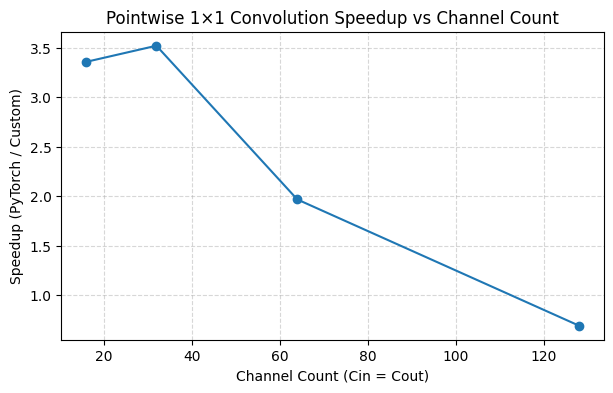

In [ ]:
plt.figure(figsize=(7,4))
plt.plot(df["Channels"], df["Speedup"], marker="o")
plt.xlabel("Channel Count (Cin = Cout)")
plt.ylabel("Speedup (PyTorch / Custom)")
plt.title("Pointwise 1×1 Convolution Speedup vs Channel Count")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


In [ ]:
shapes = [
    (1, 16, 112, 112),
    (1, 32, 56, 56),
    (1, 64, 28, 28),
]

results = []

for (N, C, H, W) in shapes:
    x = torch.randn(N, C, H, W, device="cuda", dtype=torch.float16)
    w = torch.randn(C, 1, 3, 3, device="cuda", dtype=torch.float16)

    t_pt = bench(lambda: F.conv2d(x, w, None, 1, 1, 1, C))
    t_cu = bench(lambda: dwext.dwconv3x3_fp16(x, w))

    results.append((C, H, W, t_pt, t_cu, t_pt / t_cu))

for r in results:
    print(f"C={r[0]:3d}, H=W={r[1]:3d} | PT={r[3]:.6f} ms | CU={r[4]:.6f} ms | speedup={r[5]:.2f}×")


C= 16, H=W=112 | PT=0.015174 ms | CU=0.009585 ms | speedup=1.58×
C= 32, H=W= 56 | PT=0.018954 ms | CU=0.009095 ms | speedup=2.08×
C= 64, H=W= 28 | PT=0.019047 ms | CU=0.009004 ms | speedup=2.12×


In [ ]:
import torch
import torch.nn.functional as F

# MobileNetV2 tipik pointwise shape'leri
shapes = [
    (1, 16, 112, 112),
    (1, 32, 56, 56),
    (1, 64, 28, 28),
]

results = []

for (N, C, H, W) in shapes:
    print(f"\nBenchmarking Pointwise: C={C}, H=W={H}")

    x = torch.randn(N, C, H, W, device="cuda", dtype=torch.float16)

    # Pointwise weight
    w = torch.randn(C, C, 1, 1, device="cuda", dtype=torch.float16)

    # PyTorch
    t_pt = bench(lambda: F.conv2d(x, w))        # ms

    # Custom CUDA
    t_cu = bench(lambda: pwext.pwconv1x1_fp16(x, w))  # ms

    # Throughput (samples / second)
    pt_tp = N / (t_pt * 1e-3)
    cu_tp = N / (t_cu * 1e-3)

    speedup = t_pt / t_cu

    results.append((C, H, W, t_pt, t_cu, pt_tp, cu_tp, speedup))


# Sonuçları yazdır
for r in results:
    print(
        f"C={r[0]:3d}, H=W={r[1]:3d} | "
        f"PT={r[3]:.6f} ms | "
        f"CU={r[4]:.6f} ms | "
        f"PT tp={r[5]:.0f}/s | "
        f"CU tp={r[6]:.0f}/s | "
        f"speedup={r[7]:.2f}×"
    )



Benchmarking Pointwise: C=16, H=W=112

Benchmarking Pointwise: C=32, H=W=56

Benchmarking Pointwise: C=64, H=W=28
C= 16, H=W=112 | PT=0.021380 ms | CU=0.010069 ms | PT tp=46772/s | CU tp=99315/s | speedup=2.12×
C= 32, H=W= 56 | PT=0.021131 ms | CU=0.009964 ms | PT tp=47323/s | CU tp=100366/s | speedup=2.12×
C= 64, H=W= 28 | PT=0.025985 ms | CU=0.009973 ms | PT tp=38484/s | CU tp=100273/s | speedup=2.61×
